In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import random

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from matplotlib import pyplot

## Load model

In [2]:
# 224 models
# CNNAE = tf.keras.models.load_model("./models/trainingdatasetModel.keras")
# CNNAE = tf.keras.models.load_model("./models/trainingdatasetModel2.keras")
# CNNAE = tf.keras.models.load_model("./models/trainingdatasetModel3.keras")
# CNNAE = tf.keras.models.load_model("./models/trainingdatasetModel4Simple.keras")
# CNNAE = tf.keras.models.load_model("./models/trainingdatasetModel5CNNAEpyramid.keras") 

# 448 models
# totalDatasetModel6CNNAE8-16-32.keras
# totalDatasetModel6CNNAE4-8-16.keras

CNNAE = tf.keras.models.load_model("./models/deepModel16x3-32x3-64x3.100Epochs.keras") 

#### Some testing

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

In [4]:
# Function to generate input images that maximize filter activations
def maximize_activation(model, layer_name, filter_index, input_shape=(224, 224, 3), iterations=100, learning_rate=0.1):
    # Create a random input image
    input_image = tf.Variable(np.random.rand(*input_shape), dtype=tf.float32)

    # Get the layer output
    layer_output = model.get_layer(name=layer_name).output

    # Define a loss function that maximizes the activation of a specific filter
    loss_function = tf.keras.losses.MeanSquaredError(reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE)

    # Create a model to get the output of the specified layer
    activation_model = Model(inputs=model.input, outputs=layer_output)

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    for _ in range(iterations):
        with tf.GradientTape() as tape:
            # Get the activations of the target filter
            activations = activation_model(tf.expand_dims(input_image, axis=0))[:,:,:,filter_index-1]

            # Define the loss based on the activation of the filter
            loss = -tf.reduce_mean(activations) # Negative for maximization

        gradients = tape.gradient(loss, input_image)
        optimizer.apply_gradients([(gradients, input_image)])

    return input_image.numpy()


In [5]:
def get_top_activating_images(model, layer_name, filter_index, images, top_n=1):
    """
    Finds the top_n images that activate a given filter the most.
    """
    layer_output = model.get_layer(layer_name).output
    activation_model = Model(inputs=model.input, outputs=layer_output)
    activations = activation_model.predict(images)
    filter_activations = activations[:, :, :, (filter_index-1)]
    
    # Get indices of the top_n activations
    top_indices = np.argsort(filter_activations.mean(axis=(1, 2)))[::-1][:top_n]

    return images[top_indices]

In [13]:
# Print model summary grouped by encoder, decoder and classification head
def get_layer_shape(layer):
    """Helper function to safely get layer output shape"""
    try:
        return layer.output_shape
    except AttributeError:
        return None

# Encoder layer names based on model architecture
encoder_layers = [
    'input_1',              # Input layer
    'conv2d',              # First conv block
    'conv2d_1',
    'max_pooling2d',
    'conv2d_2',            # Second conv block
    'conv2d_3',
    'max_pooling2d_1',
    'conv2d_4',            # Third conv block
    'conv2d_5',
    'max_pooling2d_2'      # Final encoding
]

# Decoder layer names
decoder_layers = [
    'conv2d_transpose',    # First upsampling block
    'conv2d_6',
    'conv2d_transpose_1',  # Second upsampling block
    'conv2d_7',
    'conv2d_transpose_2',  # Third upsampling block
    'conv2d_8',
    'decoder_output'       # Final output
]

# Classification head layer names
classifier_layers = [
    'flatten',
    'dense',
    'composer_output',
    'piece_output',
    'style_output'
]

print("Encoder layers:")
for layer in CNNAE.layers:
    if layer.name in encoder_layers:
        shape = get_layer_shape(layer)
        if shape:
            print(f"  {layer.name}: {shape}")

print("\nDecoder layers:")
for layer in CNNAE.layers:
    if layer.name in decoder_layers:
        shape = get_layer_shape(layer)
        if shape:
            print(f"  {layer.name}: {shape}")

print("\nClassification head layers:")
for layer in CNNAE.layers:
    if layer.name in classifier_layers:
        shape = get_layer_shape(layer)
        if shape:
            print(f"  {layer.name}: {shape}")

Encoder layers:

Decoder layers:

Classification head layers:


In [6]:
CNNAE.layers

[<InputLayer name=input_layer, built=True>,
 <Conv2D name=conv2d, built=True>,
 <BatchNormalization name=batch_normalization, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <BatchNormalization name=batch_normalization_1, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Dropout name=dropout, built=True>,
 <Conv2D name=conv2d_2, built=True>,
 <BatchNormalization name=batch_normalization_2, built=True>,
 <Conv2D name=conv2d_3, built=True>,
 <BatchNormalization name=batch_normalization_3, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Conv2D name=conv2d_4, built=True>,
 <BatchNormalization name=batch_normalization_4, built=True>,
 <Conv2D name=conv2d_5, built=True>,
 <BatchNormalization name=batch_normalization_5, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Conv2DTranspose name=conv2d_transpose, built=True>,
 <BatchNormalization name=batch_normalization_6, 

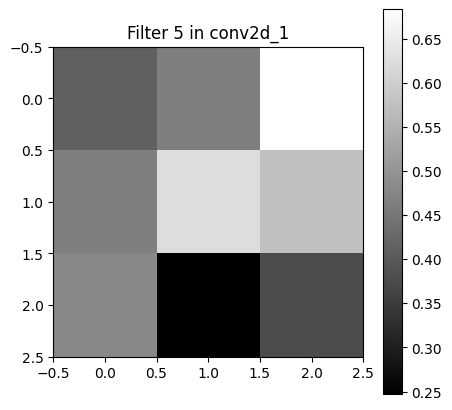

ValueError: Input 0 of layer "functional_14" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(32, 448, 448, 3)

In [85]:
# Select layers and filters
layer_name = 'conv2d_1'  # @param {type:"string"}
# Index subtracts 1 to match images...
filter_index = 5
numOfImages = 5

# Plot filter
tempLayer = CNNAE.get_layer(layer_name)
filters, biases = tempLayer.get_weights()

# Choose the specific filter to visualize (e.g., filter index 5)
chosen_filter = filters[:, :, :, filter_index]
# normalized_filter = filters[:, :, :, filter_index]

# Normalize the filter to be in the range [0, 1] for visualization
chosen_filter_min = np.min(chosen_filter)
chosen_filter_max = np.max(chosen_filter)
normalized_filter = (chosen_filter - chosen_filter_min) / (chosen_filter_max - chosen_filter_min)

# Plot the filter (3x3 filter visualization)
plt.figure(figsize=(5, 5))
plt.imshow(normalized_filter[:, :, 0], cmap='gray')  # Plot the first channel if it's RGB
plt.colorbar()
plt.title(f"Filter {filter_index} in {layer_name}")
plt.show()

# ————————————————————————————————————————

# Display the top activating images
top_images = get_top_activating_images(CNNAE, layer_name, filter_index, train_images, top_n=numOfImages)
fig, axes = plt.subplots(1, len(top_images), figsize=(12, 4))  
fig.suptitle(f"Top {numOfImages} images for filter {filter_index} in layer '{layer_name}'", fontsize=14)

for i, img in enumerate(top_images):
    axes[i].imshow(img)
    axes[i].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ————————————————————————————————————————

# Plot idealized image
maximized_image = maximize_activation(CNNAE, layer_name, filter_index, input_shape=(448, 448, 3))
plt.imshow(maximized_image[:, :, 0], cmap='gray')

## From gemini

In [86]:
from tensorflow.keras.utils import load_img
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from keras.applications.resnet50 import preprocess_input

In [87]:
CNNAE.layers

[<InputLayer name=input_layer, built=True>,
 <Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Conv2D name=conv2d_2, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>,
 <Conv2DTranspose name=conv2d_transpose, built=True>,
 <Conv2DTranspose name=conv2d_transpose_1, built=True>,
 <Conv2DTranspose name=conv2d_transpose_2, built=True>,
 <Conv2D name=conv2d_3, built=True>]

In [88]:
# Determine which layers to examine
# layer_names = ["conv2d","conv2d_1","conv2d_2",
#                "conv2d_3","conv2d_4","conv2d_5",
#                "conv2d_6","conv2d_7", "conv2d_8"] # 9 is the output for the 9 layer cnn

layer_names = ["conv2d","conv2d_1","conv2d_2"]

activation_model = Model(inputs=CNNAE.input, 
                         outputs=[CNNAE.get_layer(name).output for name in layer_names])

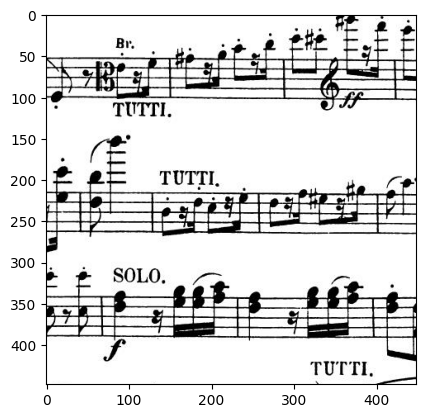

In [96]:
# Load and preprocess the image

import numpy as np
from tensorflow.keras.preprocessing import image

# 7 is scalar
img = train_images[27].copy()
plt.imshow(img, cmap='gray')

# img_path = 'path/to/your/image.jpg'
# img = image.load_img(img_path, target_size=(224, 224))  # Adjust target_size as needed

img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)  # Add a batch dimension
img_tensor /= 255.  # Normalize pixel values

In [97]:
activations = activation_model.predict(img_tensor)

ValueError: Input 0 of layer "functional_15" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(1, 448, 448, 3)

In [33]:
# Set columns and rows for each layer. MxN must be less than the number of filters in each layer.
def plotActivationsBasedOnImage(columnsSet, rowsSet):
    columns = columnsSet
    rows = rowsSet
    for ftr in activations:
        fit = plt.figure(figsize=(12,12))
        for i in range(1, columns * rows+1):
            fig = plt.subplot(rows, columns, i)
            fig.set_xticks([])
            fig.set_yticks([])
            # pyplot.imshow(ftr[0, :, :, i-1], cmap='viridis')
            # pyplot.imshow(ftr[0, :, :, i-1], cmap='gray')
            pyplot.imshow(ftr[0, :, :, i-1], cmap='gray')
    return

In [ ]:
def plotActivationsBasedOnImage(activations):
    """
    Plot activations for each layer of the CNN, with one row per layer.
    Each row shows all filters for that layer with enhanced contrast.
    All activations are resized to be consistently visible.
    
    Args:
        activations: List of activation arrays from the model
    """
    num_layers = len(activations)
    
    # Create figure with a row for each layer
    fig = plt.figure(figsize=(20, 4 * num_layers))
    
    for layer_idx, layer_activation in enumerate(activations):
        num_filters = layer_activation.shape[-1]
        
        # For each filter in the layer
        for filter_idx in range(num_filters):
            # Create subplot in the current row
            ax = plt.subplot(num_filters, num_layers, layer_idx * num_filters + filter_idx + 1)
            
            # Remove ticks
            ax.set_xticks([])
            ax.set_yticks([])
            
            # Get activation data
            activation = layer_activation[0, :, :, filter_idx]
            
            # Resize activation to consistent size if needed
            if activation.shape[0] < 224:  # Resize smaller activations to be more visible
                activation = tf.image.resize(activation[..., tf.newaxis], [224, 224])
                activation = activation.numpy().squeeze()
            
            # Enhance contrast using percentile normalization
            # More aggressive contrast enhancement for deeper layers
            p_low = 1 + (layer_idx * 3)    # Increases with depth: 1, 4, 7
            p_high = 99 - (layer_idx * 3)  # Decreases with depth: 99, 96, 93
            vmin = np.percentile(activation, p_low)
            vmax = np.percentile(activation, p_high)
            
            # Plot with enhanced contrast
            plt.imshow(activation, cmap='gray', vmin=vmin, vmax=vmax, interpolation='nearest')
            
            # Add title for first filter in each row
            if filter_idx == 0:
                ax.set_ylabel(f'Layer {layer_idx+1}\n({num_filters} filters)', 
                            rotation=0, 
                            horizontalalignment='right',
                            verticalalignment='center')
    
    plt.suptitle('Layer Activations (Size and Contrast Enhanced)', y=1.02, fontsize=14)
    plt.tight_layout()
    return fig

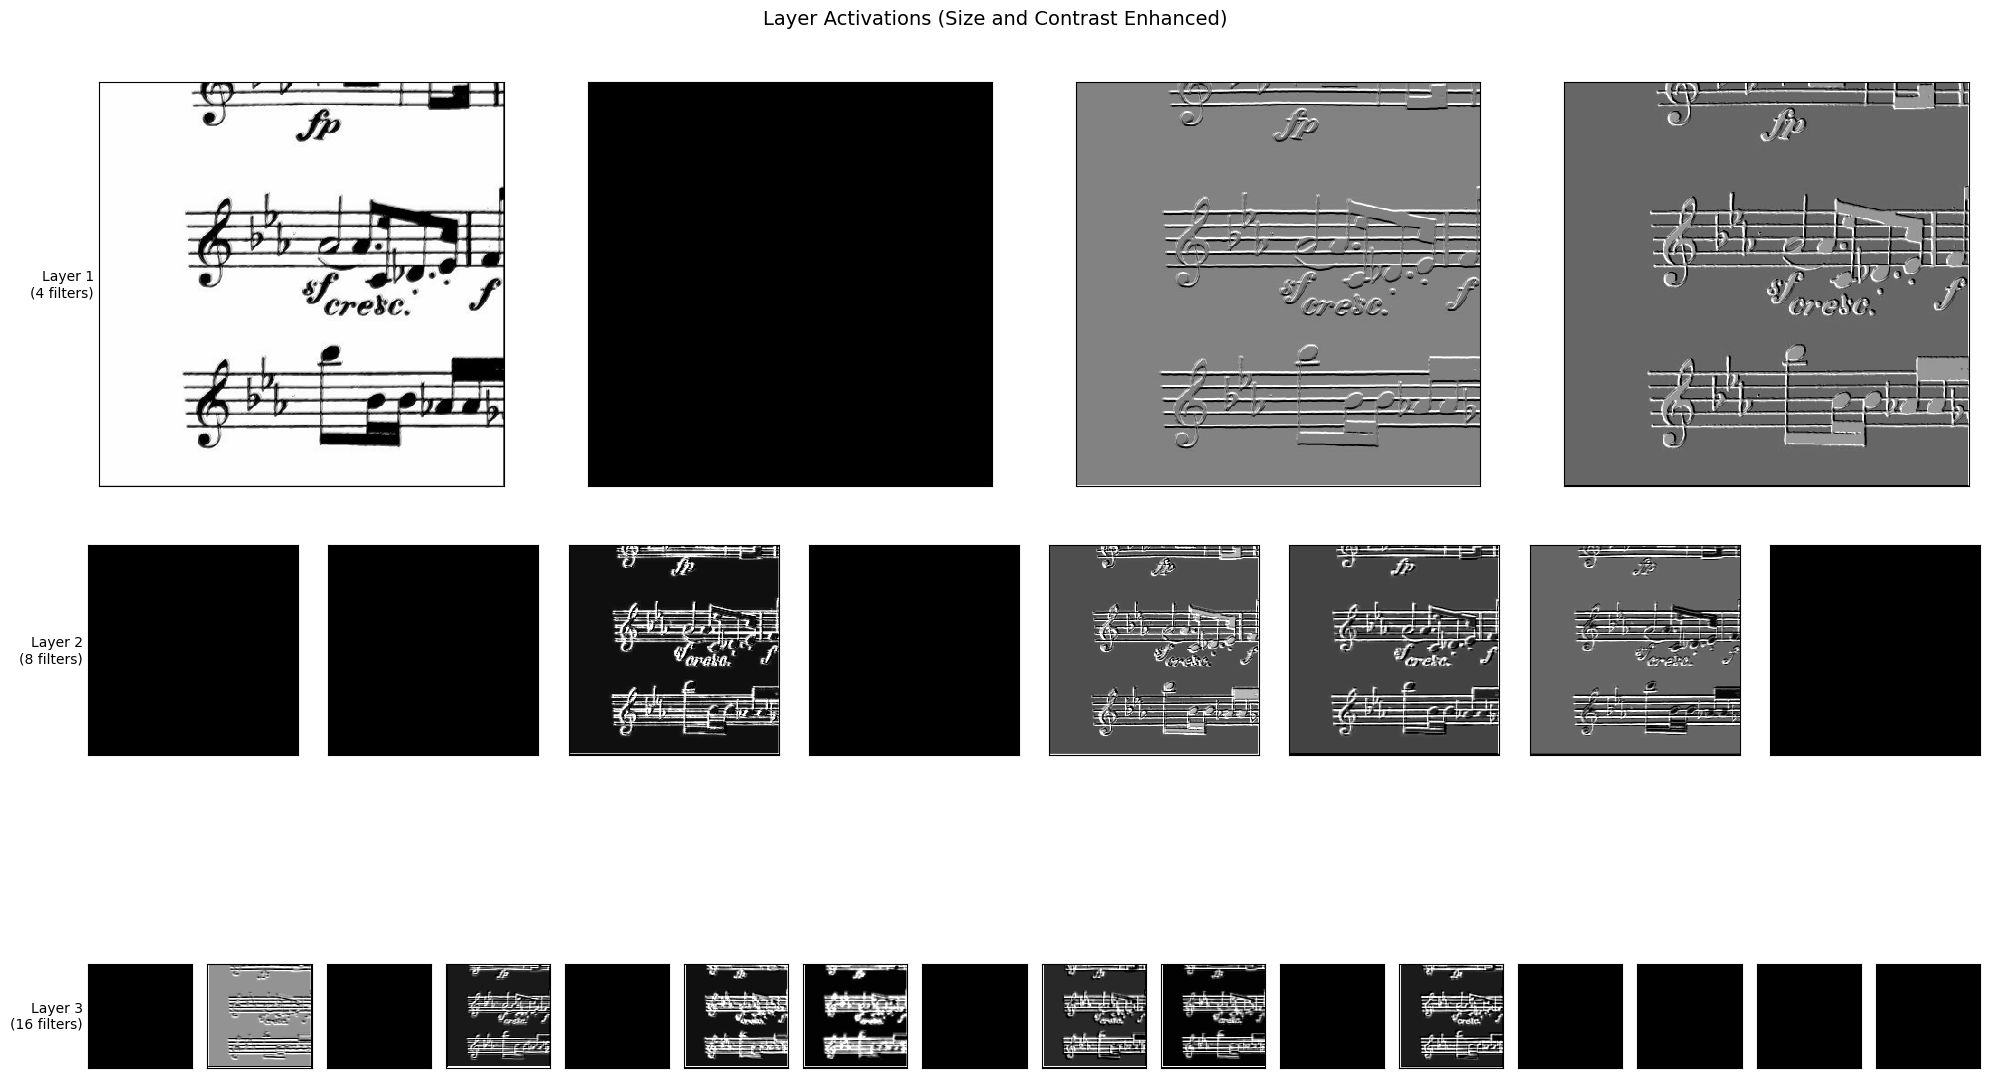

In [79]:
# Get activations using your existing activation_model
# activations = activation_model.predict(img_tensor)

# Plot the activations
fig = plotActivationsBasedOnImage(activations)
plt.show()

## Show top filters per image

In [522]:

import numpy as np
def get_top_activating_filters(model, image, layer_name, top_n=5):
    """
    Returns the indices of the top_n filters with the highest activation for a given image and layer.
    """
    layer_output = model.get_layer(layer_name).output
    activation_model = Model(inputs=model.input, outputs=layer_output)
    activations = activation_model.predict(np.expand_dims(image, axis=0))  # Add batch dimension
    
    # Assuming activations shape is (1, height, width, num_filters)
    filter_activations = activations[0].mean(axis=(0, 1)) # Average across height and width

    # Get indices of the top_n activations
    top_indices = np.argsort(filter_activations)[::-1][:top_n]
    return top_indices


In [523]:
def get_lowest_activating_filters(model, image, layer_name, top_n=5):
    """
    Returns the indices of the top_n filters with the lowest activation for a given image and layer.
    """
    layer_output = model.get_layer(layer_name).output
    activation_model = Model(inputs=model.input, outputs=layer_output)
    activations = activation_model.predict(np.expand_dims(image, axis=0))  # Add batch dimension
    
    # Assuming activations shape is (1, height, width, num_filters)
    filter_activations = activations[0].mean(axis=(0, 1)) # Average across height and width

    # Get indices of the top_n activations
    top_indices = np.argsort(filter_activations)[:top_n]
    return top_indices

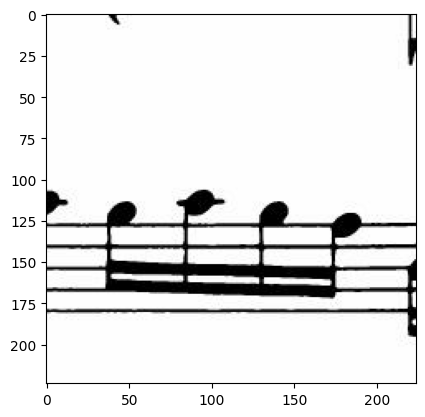

In [524]:
image_index = 70
img = train_images[image_index].copy()
plt.imshow(img, cmap='gray')

In [525]:
get_top_activating_filters(CNNAE, img, "conv2d_2")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([68, 32, 86, 50, 63])

In [526]:
get_lowest_activating_filters(CNNAE, img, "conv2d_2")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([73, 53, 56, 19, 39])

In [527]:
# Example usage (assuming you have an image and the model loaded):
# image_index = 0  # Index of the image in train_images
# image = train_images[image_index]

# img
layer_name = 'conv2d'  # Replace with the actual layer name
top_filter_indices = get_top_activating_filters(CNNAE, img, "conv2d_2", top_n=5)
lowest_filter_indices = get_lowest_activating_filters(CNNAE, img, "conv2d_2", top_n=5)
print(f"Top 5 activating filters for image {image_index} in layer '{layer_name}': {top_filter_indices}")
print(f"Top 5 activating filters for image {image_index} in layer '{layer_name}': {lowest_filter_indices}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Top 5 activating filters for image 70 in layer 'conv2d': [68 32 86 50 63]
Top 5 activating filters for image 70 in layer 'conv2d': [73 53 56 19 39]


In [528]:
def visualize_filter(model, image, layer_name, filter_index):
    """Visualizes an image through a specific filter."""
    layer_output = model.get_layer(layer_name).output
    activation_model = Model(inputs=model.input, outputs=layer_output)
    activations = activation_model.predict(np.expand_dims(image, axis=0))
    filter_activation = activations[0, :, :, filter_index]
    plt.imshow(filter_activation, cmap='viridis') # You can change the colormap if needed
    plt.title(f"Image through filter {filter_index} in layer '{layer_name}'")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


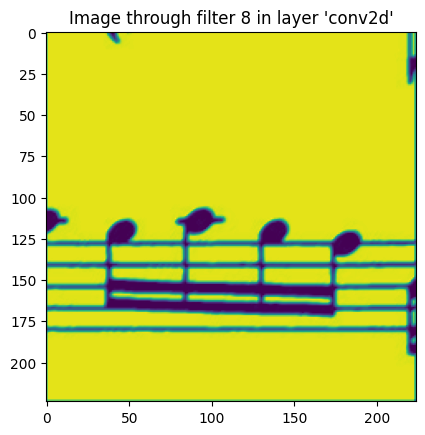

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


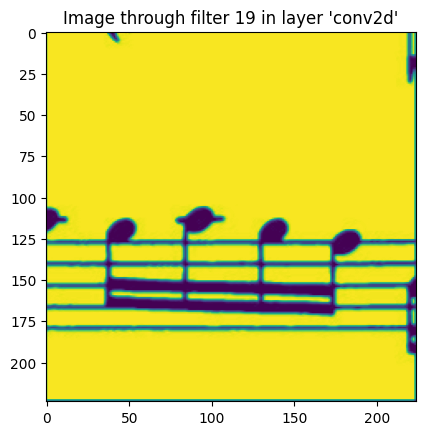

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


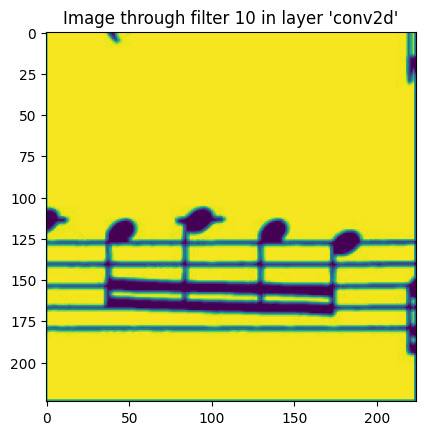

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


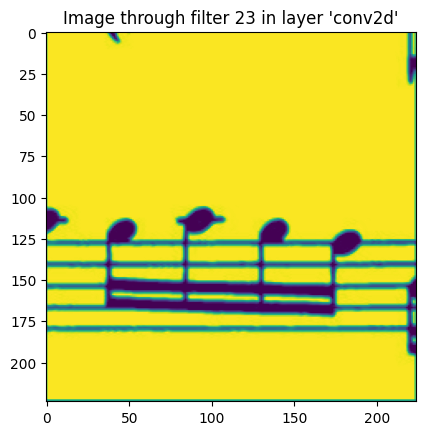

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


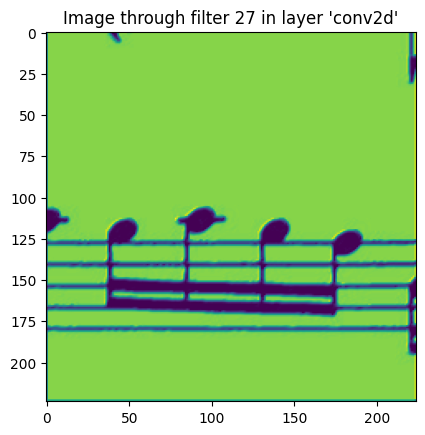

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


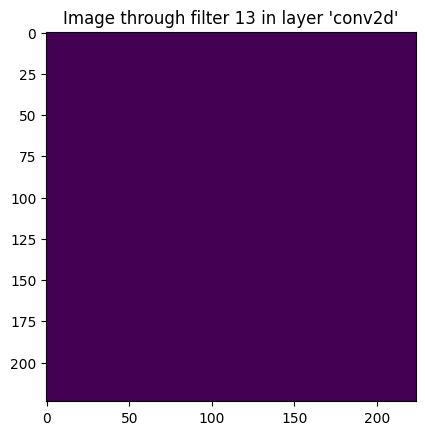

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


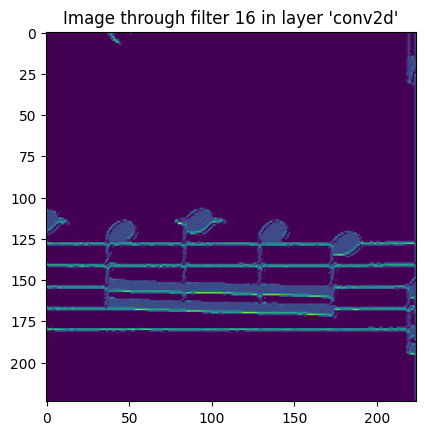

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


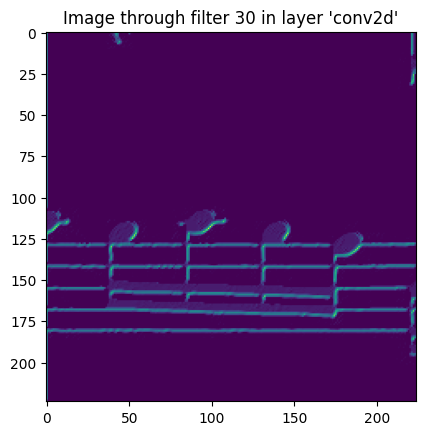

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


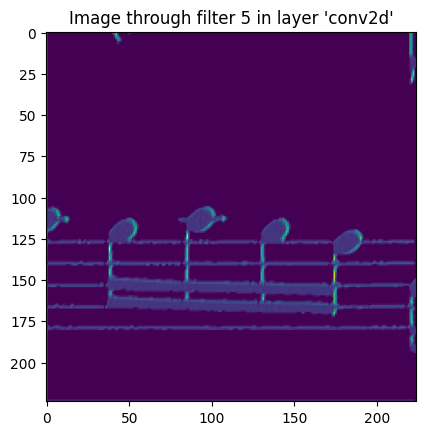

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


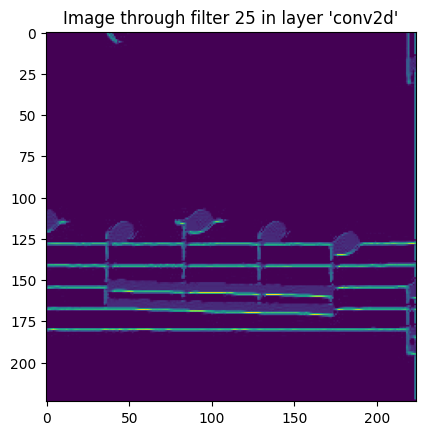

In [529]:
# Example usage (assuming you have an image and top filters):
top_filters = get_top_activating_filters(CNNAE, img, 'conv2d')
low_filters = get_lowest_activating_filters(CNNAE, img, 'conv2d')

for filter_index in top_filters:
    visualize_filter(CNNAE, train_images[image_index], 'conv2d', filter_index)

for filter_index in low_filters:
    visualize_filter(CNNAE, train_images[image_index], 'conv2d', filter_index)

Encoder layers:


AttributeError: 'InputLayer' object has no attribute 'output_shape'